# Gaussian MCMC — BFFG with a hand-rolled kernel

This notebook is about the **BFFG prebuilt** (`hyperiax.prebuilt.bffg`) and how to wrap it into a custom MCMC kernel that NumPyro's `MCMC` driver can run. The setup is a depth-4 binary Gaussian tree (31 nodes, 16 leaves, unit edges):

$$x_v \mid x_{\text{pa}(v)} \sim \mathcal{N}(x_{\text{pa}(v)},\, \sigma^2 I), \qquad y_\ell = x_\ell + \mathcal{N}(0, \tau^2),$$

and we want the joint posterior of the latent paths and the hyperparameters $(\sigma^2, \tau^2)$.

## What BFFG gives you

Following van der Meulen & Sommer (2025) §6.1 / Theorem 14, BFFG provides:

1. A **backward filter** (`discrete_bf_sweep`) that propagates canonical-form messages $(H_v, F_v)$ from the leaves up to the root.
2. A **guided forward sampler** (`discrete_fg_sweep`) that draws each $x_v$ conditional on its parent *and* the downstream leaf observations, accumulating a per-edge **importance-weight correction** $\log w_v$.
3. In the linear-Gaussian case where the auxiliary process equals the true process, $\sum \log w_v \equiv 0$ (Theorem-14 collapse) — we verify this empirically below.

The result is a pure $(z, \log\theta) \mapsto (x, \sum \log w)$ map. To turn it into MCMC we need a *kernel* that proposes moves in $z$ and $\log\theta$ and accepts them against the BFFG-implied target.

## What we'll build

A two-block Metropolis-within-Gibbs kernel:

- **pCN block on $z$** — Crank-Nicolson proposal $z' = \sqrt{1-\beta^2}\,z + \beta\,\varepsilon$. Reversible w.r.t. the standard-normal prior on $z$; in the Theorem-14-collapsed regime its accept probability is exactly 1.
- **RW block on $\log\theta$** — symmetric Gaussian random walk; standard Metropolis acceptance against the joint potential.

The kernel is a NumPyro `MCMCKernel` subclass — about 30 lines. NumPyro's `MCMC` driver handles warmup, chains, and the JIT plumbing. *NumPyro acts purely as the engine here; the proposal logic is ours.*

(Notebook [`06_gaussian_nuts.ipynb`](06_gaussian_nuts.ipynb) keeps the model identical but swaps this hand-rolled kernel for NumPyro's built-in **NUTS**, which uses gradients of the same potential. That's a separate story.)

## Outline

1. Setup — tree, schema, synthetic data, constants, BFFG-guided forward map
2. Closed-form marginal $\log p(y \mid \theta)$ (the ground-truth landmark)
3. BFFG mechanics walkthrough — backward filter, guided forward, one trajectory
4. Empirical Theorem-14 collapse — $\sum \log w \equiv 0$ to machine precision
5. NumPyro model wrapping BFFG
6. Custom `RWpCNKernel` — implementation walkthrough
7. Run the chain — 4 chains × 8000 samples
8. Verification — chain histogram vs analytic grid posterior
9. Non-linear teaser — state-dependent covariance breaks the collapse
10. Recap and bridges to notebooks 06 (NUTS) and 07 (SDE bridges)


## 1. Setup

We build the example from scratch so this notebook is self-contained: a depth-4 binary tree, the linear-Gaussian model, synthetic leaf observations, the closed-form marginal likelihood, and the BFFG-guided forward map.

### Imports + tree topology

In [1]:
%matplotlib inline
import time
from collections import namedtuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC
from numpyro.infer.mcmc import MCMCKernel
from numpyro.infer.util import initialize_model
from numpyro.diagnostics import effective_sample_size, gelman_rubin

import hyperiax as hx
from hyperiax.prebuilt.bffg import (
    discrete_bf_sweep,
    discrete_fg_sweep,
    discrete_forward_sweep,
    discrete_schema,
    init_discrete_tree,
)

D = 1                                          # scalar latent at every node
topo = hx.symmetric_topology(depth=4, degree=2)
N_NODES = topo.size                            # 31
N_LEAVES = int(topo.is_leaf.sum())             # 16
SCHEMA = discrete_schema(d=D)                  # {val, z, ptnl, prec, log_corr}
empty = hx.Tree.empty(topo, SCHEMA)
ROOT_VAL = jnp.zeros((D,))                     # pin root at 0

print(f"tree: {N_NODES} nodes, {N_LEAVES} leaves, depth {topo.depth}")


/Users/vbd402/Projects/hyperiax/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tree: 31 nodes, 16 leaves, depth 4


### True parameters + MCMC constants

In [2]:
SIGMA_SQ_TRUE = 0.5    # transition variance
TAU_SQ_TRUE = 0.1      # observation variance
PRIOR_STD = 2.0        # N(0, PRIOR_STD^2) prior on each log theta
BETA_PCN = 0.20        # pCN step size
RW_SCALE = 0.80        # random-walk step size in log-theta

print(f"truth: sigma^2 = {SIGMA_SQ_TRUE}, tau^2 = {TAU_SQ_TRUE}")
print(f"prior: N(0, {PRIOR_STD}^2) on each log theta")
print(f"kernel constants: pCN beta = {BETA_PCN}, RW scale = {RW_SCALE}")


truth: sigma^2 = 0.5, tau^2 = 0.1
prior: N(0, 2.0^2) on each log theta
kernel constants: pCN beta = 0.2, RW scale = 0.8


### Linear-Gaussian model + matching auxiliary

`mean_fn` and `covar_fn` are the true transition $\mathcal{N}(x_{\text{pa}}, \sigma^2 I)$. The auxiliary triple `(prxy_scale_fn, prxy_shift_fn, prxy_covar_fn) = (I, 0, \sigma^2 I)` matches the truth exactly — this is the regime where Theorem 14 §6.1 collapses the importance weight to 0.

In [3]:
def mean_fn(x_pa, params):
    return x_pa  # Phi = I


def covar_fn(x_pa, params):
    return params["sigma_sq"] * jnp.eye(D)  # state-independent


def prxy_scale_fn(anchor, params):
    return jnp.eye(D)  # Phi = I (auxiliary matches truth)


def prxy_shift_fn(anchor, params):
    return jnp.zeros(D)  # beta = 0


def prxy_covar_fn(anchor, params):
    return params["sigma_sq"] * jnp.eye(D)  # Q matches truth


### Synthetic data — forward simulation under the truth

`discrete_forward_sweep` walks root → leaves drawing each $x_v \sim \mathcal{N}(x_{\text{pa}}, \sigma^2 I)$ via reparameterisation `x_v = x_pa + sqrt(sigma_sq) * z_v`. The leaves are then perturbed with $\mathcal{N}(0, \tau^2)$ to give the observations the rest of the notebook treats as data.

In [4]:
_sweep_forward = discrete_forward_sweep(mean_fn, covar_fn)
_k_path, _k_obs = jax.random.split(jax.random.PRNGKey(202605), 2)

_gt = empty.at[topo.is_root].set(val=ROOT_VAL)
_gt = _gt.set(z=jax.random.normal(_k_path, (N_NODES, D)))
_gt = _sweep_forward(_gt, params={"sigma_sq": SIGMA_SQ_TRUE})

leaf_truth = _gt.val[topo.is_leaf]
_obs_noise = jnp.sqrt(TAU_SQ_TRUE) * jax.random.normal(_k_obs, (N_LEAVES, D))
leaf_obs = leaf_truth + _obs_noise          # (N_LEAVES, D)
print(f"first 4 leaf observations: {np.asarray(leaf_obs[:4, 0])}")


first 4 leaf observations: [-3.2318456 -1.7759498 -3.105866  -1.8258889]


### Closed-form marginal $\log p(y \mid \theta)$ via the MRCA-depth kernel

For our depth-4 binary tree with unit edges and $x_{\text{root}} = 0$, the leaves are jointly multivariate normal:

$$y \sim \mathcal{N}\!\bigl(0,\;\; \sigma^2 K + \tau^2 I\bigr), \qquad K_{ij} = \text{depth}\bigl(\text{MRCA}(i, j)\bigr).$$

$K$ is computed once from the topology. This will be the ground-truth landmark for verifying the BFFG-MCMC chain at the end.

In [5]:
def _root_to_mrca_depth(topo):
    # (n_leaves, n_leaves): depth of MRCA(leaf_i, leaf_j) above the root.
    parents = np.asarray(topo.parents)
    node_depths = np.asarray(topo.node_depths)

    def path_to_root(node):
        path = [int(node)]
        while path[-1] != 0:
            path.append(int(parents[path[-1]]))
        return path[::-1]

    leaf_idx = np.where(np.asarray(topo.is_leaf))[0]
    paths = [path_to_root(int(li)) for li in leaf_idx]
    L = len(leaf_idx)
    K = np.zeros((L, L), dtype=np.float32)
    for i, pi in enumerate(paths):
        for j, pj in enumerate(paths):
            mrca = 0
            for a, b in zip(pi, pj):
                if a == b:
                    mrca = a
                else:
                    break
            K[i, j] = float(node_depths[mrca])
    return K


MRCA_K = jnp.asarray(_root_to_mrca_depth(topo))
Y_VEC = leaf_obs.squeeze(-1)
I_LEAVES = jnp.eye(N_LEAVES)


@jax.jit
def marginal_loglik(log_sigma_sq, log_tau_sq):
    Sigma = jnp.exp(log_sigma_sq) * MRCA_K + jnp.exp(log_tau_sq) * I_LEAVES
    return jax.scipy.stats.multivariate_normal.logpdf(
        Y_VEC, mean=jnp.zeros(N_LEAVES), cov=Sigma
    )


print(f"log p(y | theta_true) = {float(marginal_loglik(jnp.log(SIGMA_SQ_TRUE), jnp.log(TAU_SQ_TRUE))):.4f}")


log p(y | theta_true) = -24.4213


### BFFG-guided forward map

The three sweeps `init_discrete_tree → discrete_bf_sweep → discrete_fg_sweep` compose into a pure $(z, \log\theta) \mapsto (x, \sum \log w)$ map. We define the sweeps and the wrapper once here; the rest of the notebook walks through what each piece does (§ 3) and then plugs the wrapper into the MCMC target (§ 5–6).

In [6]:
bf_sweep = discrete_bf_sweep(prxy_scale_fn, prxy_shift_fn, prxy_covar_fn)
fg_sweep = discrete_fg_sweep(
    mean_fn, covar_fn, prxy_scale_fn, prxy_shift_fn, prxy_covar_fn
)


@jax.jit
def bffg_guided_forward(z, log_theta):
    # init -> backward filter -> guided forward.
    # Returns (per-node sampled value x, total Theorem-14 log_corr).
    sigma_sq = jnp.exp(log_theta[0])
    tau_sq = jnp.exp(log_theta[1])
    params = {"sigma_sq": sigma_sq}

    t = init_discrete_tree(empty, leaf_obs, obs_var=tau_sq, d=D, root_val=ROOT_VAL)
    t = bf_sweep(t, params=params)
    t = t.set(z=z[:, None])
    t = fg_sweep(t, params=params)
    return t.val.squeeze(-1), t.log_corr.sum()


## 2. The log-likelihood landscape

A quick visual of `marginal_loglik` shows that the closed-form $\log p(y \mid \theta)$ has its peak around $(\sigma^2, \tau^2)_\text{MLE}$ near the truth, but is fairly flat in $\tau^2$ — with only 16 leaves, $\tau^2$ is weakly identified. We'll see exactly this shape in the posterior at the end.

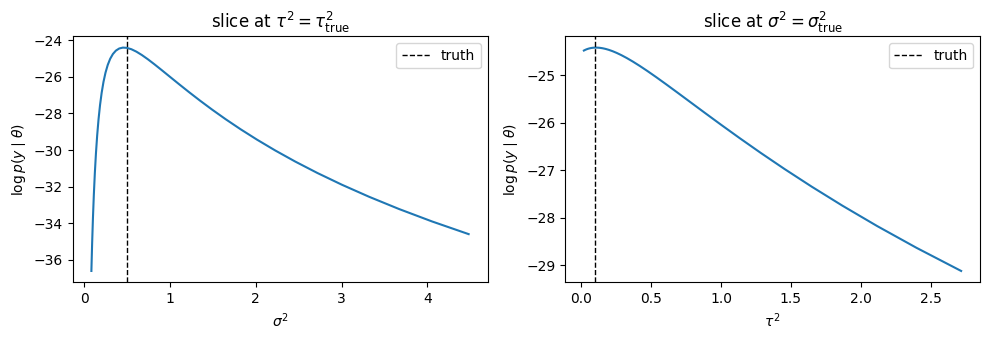

log p(y | theta_true) = -24.4213


In [7]:
log_sigmas = jnp.linspace(-2.5, 1.5, 41)
log_taus = jnp.linspace(-4.0, 1.0, 41)
slice_s = jax.vmap(lambda ls: marginal_loglik(ls, jnp.log(TAU_SQ_TRUE)))(log_sigmas)
slice_t = jax.vmap(lambda lt: marginal_loglik(jnp.log(SIGMA_SQ_TRUE), lt))(log_taus)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(np.exp(log_sigmas), np.asarray(slice_s))
ax[0].axvline(SIGMA_SQ_TRUE, ls="--", color="k", lw=1, label="truth")
ax[0].set_xlabel(r"$\sigma^2$"); ax[0].set_ylabel(r"$\log p(y \mid \theta)$")
ax[0].set_title(r"slice at $\tau^2 = \tau^2_{\text{true}}$"); ax[0].legend()

ax[1].plot(np.exp(log_taus), np.asarray(slice_t))
ax[1].axvline(TAU_SQ_TRUE, ls="--", color="k", lw=1, label="truth")
ax[1].set_xlabel(r"$\tau^2$"); ax[1].set_ylabel(r"$\log p(y \mid \theta)$")
ax[1].set_title(r"slice at $\sigma^2 = \sigma^2_{\text{true}}$"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"log p(y | theta_true) = {float(marginal_loglik(jnp.log(SIGMA_SQ_TRUE), jnp.log(TAU_SQ_TRUE))):.4f}")


## 3. BFFG mechanics — what the three sweeps do

The wrapper `bffg_guided_forward` is short but does a lot inside. Let's expand it one sweep at a time:

- **`init_discrete_tree(tree, leaf_obs, obs_var=tau_sq, d, root_val)`** — seeds the leaf canonical messages $H_\ell = 1/\tau^2 \cdot I$, $F_\ell = y_\ell / \tau^2$ and pins the root.
- **`discrete_bf_sweep`** — the backward filter. Propagates $(H_v, F_v)$ child → parent at every level: $H_v = \sum_c \Phi^\top C_c^{-1} \Phi$, $F_v = \sum_c \Phi^\top C_c^{-1}(F_c - H_c \beta)$ with $C_c = I + H_c Q$.
- **`discrete_fg_sweep`** — the guided forward. Given a parent state and standard-normal noise $z_v$, samples $x_v$ from the canonical-form proposal $\mathcal{N}^{\text{can}}(F_v + Q^{-1}\mu,\, H_v + Q^{-1})$ and writes the per-edge importance weight $\log w_v$ to `log_corr`.

The linear-auxiliary-equals-truth choice we made in § 1 means every $\log w_v$ vanishes by Theorem 14 §6.1 — we verify that empirically in § 4.

In [8]:
params_true = {"sigma_sq": SIGMA_SQ_TRUE}

t = init_discrete_tree(empty, leaf_obs, obs_var=TAU_SQ_TRUE, d=D, root_val=ROOT_VAL)
print("after init_discrete_tree:")
print(f"  prec at leaves = 1/tau^2 = {float(t.prec[topo.is_leaf][0, 0, 0]):.4f}")
print(f"  ptnl at leaves = y/tau^2 (first three) = {np.asarray(t.ptnl[topo.is_leaf, 0])[:3]}")

t = bf_sweep(t, params=params_true)
print("\nafter discrete_bf_sweep (root canonical message):")
print(f"  H_root = {float(t.prec[0, 0, 0]):.4f}")
print(f"  F_root = {float(t.ptnl[0, 0]):.4f}")


after init_discrete_tree:
  prec at leaves = 1/tau^2 = 10.0000
  ptnl at leaves = y/tau^2 (first three) = [-32.318455 -17.759499 -31.058659]



after discrete_bf_sweep (root canonical message):
  H_root = 2.1053
  F_root = -2.2076


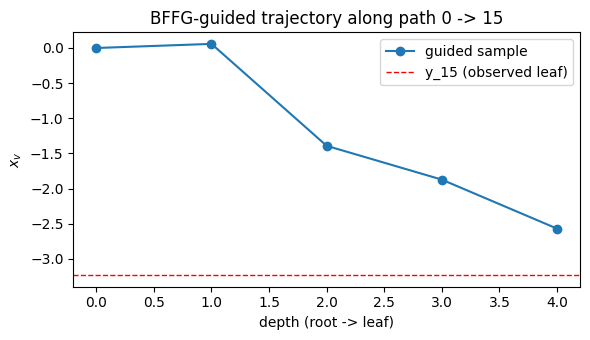

sum log_corr along the whole tree = 0.00e+00  (Theorem-14 collapse)


In [9]:
# Guided forward draw: seed z ~ N(0, I), then run the down sweep.
key = jax.random.PRNGKey(0)
z = jax.random.normal(key, (N_NODES, 1))
t = t.set(z=z)
t = fg_sweep(t, params=params_true)

parents = np.asarray(topo.parents)


def path_to_leaf(leaf_idx: int) -> list[int]:
    path = [int(leaf_idx)]
    while path[-1] != 0:
        path.append(int(parents[path[-1]]))
    return path[::-1]


leaf_idx = int(np.where(np.asarray(topo.is_leaf))[0][0])
path = path_to_leaf(leaf_idx)
x_path = np.asarray(t.val[path, 0])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(len(path)), x_path, "o-", label="guided sample")
ax.axhline(float(leaf_obs[0, 0]), ls="--", color="r", lw=1, label=f"y_{leaf_idx} (observed leaf)")
ax.set_xlabel("depth (root -> leaf)")
ax.set_ylabel(r"$x_v$")
ax.set_title(f"BFFG-guided trajectory along path 0 -> {leaf_idx}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"sum log_corr along the whole tree = {float(t.log_corr.sum()):.2e}  (Theorem-14 collapse)")


## 4. Empirical Theorem-14 collapse

Theorem 14 §6.1 guarantees that when the auxiliary process *is* the true process (our setting), the importance weight $w(x) \equiv 1$ for all sampled paths, so $\sum \log w \equiv 0$. Across 500 independent noise draws at $\theta_{\text{true}}$:

500 draws at theta_true: max |sum log_corr| = 0.00e+00
all under 1e-5? True


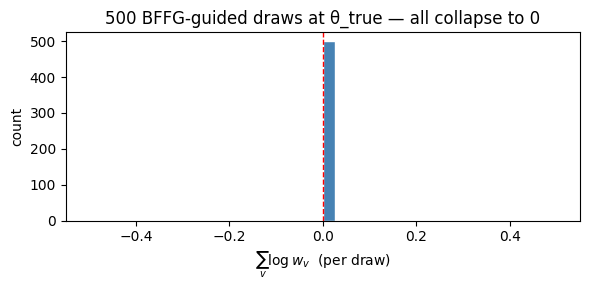

In [10]:
def sum_logw_at(z, log_theta):
    _, sum_log_corr = bffg_guided_forward(z, log_theta)
    return sum_log_corr


keys = jax.random.split(jax.random.PRNGKey(1), 500)
zs = jax.vmap(lambda k: jax.random.normal(k, (N_NODES,)))(keys)
lt_true = jnp.log(jnp.array([SIGMA_SQ_TRUE, TAU_SQ_TRUE]))
sums = jax.vmap(lambda z: sum_logw_at(z, lt_true))(zs)
sums = np.asarray(sums)

print(f"500 draws at theta_true: max |sum log_corr| = {np.max(np.abs(sums)):.2e}")
print(f"all under 1e-5? {bool(np.all(np.abs(sums) < 1e-5))}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(sums, bins=40, color="steelblue", edgecolor="white")
ax.axvline(0, color="r", ls="--", lw=1)
ax.set_xlabel(r"$\sum_v \log w_v$  (per draw)")
ax.set_ylabel("count")
ax.set_title("500 BFFG-guided draws at θ_true — all collapse to 0")
plt.tight_layout(); plt.show()


This is the empirical signal that the **pCN block in our kernel will always accept** (its acceptance ratio collapses to $\exp(\Delta \sum \log w) = \exp(0) = 1$). Any deviation from $\equiv 0$ would indicate a bug in the BFFG implementation. The non-linear teaser at the end of the notebook shows what happens when this assumption breaks.

## 5. NumPyro model wrapping BFFG

The model has two latent sites: the hyperparameters $\log \theta = [\log \sigma^2, \log \tau^2]$ and the per-node noise field $z \in \mathbb{R}^{N_\text{nodes}}$. The BFFG-implied log-density plugs in via `numpyro.factor`:

$$\text{factor}_\text{bffg} \;=\; \log p(y \mid \theta) \;+\; \sum_v \log w_v(z, \theta).$$

The first term is the closed-form marginal (works as the BFFG $\log g_r(0; \theta)$ in this linear case); the second is the BFFG importance correction (identically zero here). `numpyro.factor` adds this to the joint potential the sampler sees.

In [11]:
def model():
    log_theta = numpyro.sample(
        "log_theta", dist.Normal(jnp.zeros(2), PRIOR_STD).to_event(1)
    )
    z = numpyro.sample("z", dist.Normal(jnp.zeros(N_NODES), 1.0).to_event(1))
    _, sum_log_corr = bffg_guided_forward(z, log_theta)
    log_g_r = marginal_loglik(log_theta[0], log_theta[1])
    numpyro.factor("bffg", log_g_r + sum_log_corr)


# initialize_model traces the model once and hands back a callable
# potential_fn(u) = -log_joint(u). Both sites have R support (Normal priors),
# so the unconstrained and constrained representations coincide.
mi = initialize_model(jax.random.PRNGKey(0), model, validate_grad=False)
potential_fn = mi.potential_fn
z0 = jax.random.normal(jax.random.PRNGKey(0), (N_NODES,))
U0 = float(potential_fn({"log_theta": lt_true, "z": z0}))
print(f"potential_fn ready; U(theta_true, z0) = {U0:.4f}")
print(f"sites: {dict((k, tuple(v.shape)) for k, v in mi.param_info.z.items())}")


potential_fn ready; U(theta_true, z0) = 76.9254
sites: {'log_theta': (2,), 'z': (31,)}


## 6. Custom `RWpCNKernel`

A `MCMCKernel` subclass needs three methods: `init` (initialise per-chain state), `sample` (one Metropolis step), and `postprocess_fn` (transform unconstrained → constrained if needed; identity here). Inside `sample` we do two sequential blocks per call.

### The pCN prior-cancellation line

`potential_fn` already includes the $z$-prior $\log \mathcal{N}(z; 0, I)$ because we declared $z$ with `numpyro.sample(...)`. But pCN's proposal $z' = \sqrt{1-\beta^2}\,z + \beta\,\varepsilon$ is **reversible** w.r.t. $\mathcal{N}(0, I)$, which means a correct accept ratio should use the *likelihood* only — not the prior. We subtract the $z$-prior delta back out:

$$\log\alpha_\text{pCN} \;=\; -(U' - U) \;-\; \bigl(\log\mathcal{N}(z'; 0, I) - \log\mathcal{N}(z; 0, I)\bigr).$$

That's the one extra line vs. a textbook pCN. The RW block on $\log\theta$ keeps $z$ fixed, so the $z$-prior cancels in $\Delta U$ and no correction is needed there.

In [12]:
RWpCNState = namedtuple("RWpCNState", ["u", "potential_energy", "accept", "rng_key"])


def _std_normal_logpdf(x):
    # log N(x; 0, I), up to an additive constant that cancels in deltas.
    return -0.5 * jnp.sum(x ** 2)


class RWpCNKernel(MCMCKernel):
    sample_field = "u"

    def __init__(
        self,
        potential_fn,
        *,
        beta,
        rw_scale,
        noise_site="z",
        param_sites=("log_theta",),
    ):
        self._potential_fn = potential_fn
        self._beta = beta
        self._pcn_old = jnp.sqrt(1.0 - beta ** 2)
        self._rw_scale = rw_scale
        self._noise_site = noise_site
        self._param_sites = tuple(param_sites)

    def init(self, rng_key, num_warmup, init_params, model_args, model_kwargs):
        if init_params is None:
            raise ValueError("RWpCNKernel needs explicit init_params (a dict per site).")
        return RWpCNState(init_params, self._potential_fn(init_params), jnp.zeros(2), rng_key)

    def postprocess_fn(self, model_args, model_kwargs):
        # Real-support sites: unconstrained == constrained.
        return lambda x, *a, **k: x

    def sample(self, state, model_args, model_kwargs):
        u = dict(state.u)
        U = state.potential_energy
        k_pcn, k_pcn_acc, k_rw, k_rw_acc, k_next = jax.random.split(state.rng_key, 5)

        # ── pCN block on the noise site (parameters fixed) ──
        z = u[self._noise_site]
        z_prop = self._pcn_old * z + self._beta * jax.random.normal(k_pcn, z.shape)
        U_prop = self._potential_fn({**u, self._noise_site: z_prop})
        log_alpha = (
            -(U_prop - U)
            - (_std_normal_logpdf(z_prop) - _std_normal_logpdf(z))  # prior-cancel
        )
        acc_z = jnp.log(jax.random.uniform(k_pcn_acc)) < log_alpha
        u[self._noise_site] = jnp.where(acc_z, z_prop, z)
        U = jnp.where(acc_z, U_prop, U)  # re-cache before the RW block

        # ── RW block on the parameter sites (noise fixed) ──
        rw_keys = jax.random.split(k_rw, len(self._param_sites))
        u_prop = dict(u)
        for site, key in zip(self._param_sites, rw_keys):
            u_prop[site] = u[site] + self._rw_scale * jax.random.normal(key, u[site].shape)
        U_prop = self._potential_fn(u_prop)
        acc_th = jnp.log(jax.random.uniform(k_rw_acc)) < -(U_prop - U)  # symmetric
        for site in self._param_sites:
            u[site] = jnp.where(acc_th, u_prop[site], u[site])
        U = jnp.where(acc_th, U_prop, U)

        return RWpCNState(u, U, jnp.array([acc_z, acc_th], dtype=jnp.float32), k_next)


## 7. Run the chain

4 chains × 8000 samples with overdispersed inits. NumPyro 0.21's vectorized chain mode doesn't auto-vmap a custom kernel, so we loop 4 independent single-chain runs — JAX caches the compiled program across runs, so the overhead is one compile.

In the linear-Gaussian regime we expect:

- **pCN acceptance ≈ 1.0** — the visible signature of Theorem-14 collapse.
- **RW acceptance** in $[0.30, 0.55]$ — the optimal range for a 2-D Gaussian random walk in $\log\theta$.

In [13]:
N_WARMUP, N_SAMPLES, N_CHAINS = 1000, 8000, 4

INIT_THETAS = np.array(
    [[-1.5, -2.0], [1.0, -1.0], [0.3, 0.5], [-0.5, 0.0]], dtype=np.float32
)
INIT_ZS = np.asarray(jax.random.normal(jax.random.PRNGKey(33), (N_CHAINS, N_NODES)))

kernel = RWpCNKernel(potential_fn, beta=BETA_PCN, rw_scale=RW_SCALE)
chains, accs = [], []
t0 = time.perf_counter()
for c in range(N_CHAINS):
    mc = MCMC(
        kernel,
        num_warmup=N_WARMUP,
        num_samples=N_SAMPLES,
        num_chains=1,
        progress_bar=False,
    )
    init = {"log_theta": jnp.asarray(INIT_THETAS[c]), "z": jnp.asarray(INIT_ZS[c])}
    mc.run(jax.random.PRNGKey(7 + c), init_params=init, extra_fields=("accept",))
    chains.append(np.asarray(mc.get_samples()["log_theta"]))
    accs.append(np.asarray(mc.get_extra_fields()["accept"]))
elapsed = time.perf_counter() - t0

lt = np.stack(chains)  # (chains, samples, 2)
acc = np.stack(accs)   # (chains, samples, 2): [pCN, RW]

print(f"RW/pCN: {elapsed:.1f}s   {N_CHAINS} chains x {N_SAMPLES} samples")
print(f"  acc pCN = {acc[..., 0].mean():.4f}  (Theorem-14 collapse -> ~1.0)")
print(f"  acc RW  = {acc[..., 1].mean():.4f}  (target band 0.30-0.55)")
print(f"  Rhat    = {gelman_rubin(lt)}")
print(f"  ESS     = {effective_sample_size(lt)}  (of {N_CHAINS * N_SAMPLES} draws)")


RW/pCN: 5.9s   4 chains x 8000 samples
  acc pCN = 1.0000  (Theorem-14 collapse -> ~1.0)
  acc RW  = 0.4633  (target band 0.30-0.55)
  Rhat    = [0.99996847 1.000542  ]
  ESS     = [3448.88762301 1151.18399045]  (of 32000 draws)


## 8. Verification vs the analytic grid posterior

The closed-form $\log p(y \mid \theta) + \log \pi(\log \theta)$ normalised and marginalised on a 200×200 grid is the cleanest possible reference — no MCMC bias, no sampler tuning. The chain histograms should hug the red curves to within Monte-Carlo noise.

In [14]:
n_grid = 200
log_s2 = jnp.linspace(-3.0, 2.0, n_grid)
log_t2 = jnp.linspace(-5.0, 1.0, n_grid)
dls = float(log_s2[1] - log_s2[0])
dlt = float(log_t2[1] - log_t2[0])
LS, LT = jnp.meshgrid(log_s2, log_t2, indexing="ij")


@jax.jit
def log_unnorm(ls, lt):
    return (
        marginal_loglik(ls, lt)
        + jax.scipy.stats.norm.logpdf(ls, 0.0, PRIOR_STD)
        + jax.scipy.stats.norm.logpdf(lt, 0.0, PRIOR_STD)
    )


LP = jax.vmap(jax.vmap(log_unnorm))(LS, LT)
P = jnp.exp(LP - LP.max())
P = P / (P.sum() * dls * dlt)
P_s2 = P.sum(1) * dlt
P_t2 = P.sum(0) * dls
s2g, t2g = jnp.exp(log_s2), jnp.exp(log_t2)
p_s2 = P_s2 / s2g  # density in sigma^2 space (Jacobian)
p_t2 = P_t2 / t2g


def grid_summary(natg, plog, dl):
    cdf = jnp.cumsum(plog) * dl
    q = lambda lv: float(jnp.interp(lv, cdf, natg))
    return dict(
        mean=float(jnp.sum(natg * plog) * dl),
        median=q(0.5),
        ci95=(q(0.025), q(0.975)),
    )


ana = {
    "sigma_sq": grid_summary(s2g, P_s2, dls),
    "tau_sq": grid_summary(t2g, P_t2, dlt),
}
samples = np.exp(lt.reshape(-1, 2))


def chain_summary(idx):
    q = np.quantile(samples[:, idx], [0.025, 0.5, 0.975])
    return dict(mean=float(samples[:, idx].mean()), median=float(q[1]), ci95=(float(q[0]), float(q[2])))


def fmt(s):
    return (
        f"mean={s['mean']:.4f}  median={s['median']:.4f}  "
        f"95% CI=[{s['ci95'][0]:.4f}, {s['ci95'][1]:.4f}]"
    )


for k, idx, truth in (("sigma_sq", 0, SIGMA_SQ_TRUE), ("tau_sq", 1, TAU_SQ_TRUE)):
    print(f"{k}  (truth = {truth})")
    print(f"  analytic : {fmt(ana[k])}")
    print(f"  RW/pCN   : {fmt(chain_summary(idx))}")
    print()


sigma_sq  (truth = 0.5)
  analytic : mean=0.4669  median=0.4136  95% CI=[0.1364, 1.0678]
  RW/pCN   : mean=0.4676  median=0.4222  95% CI=[0.1384, 1.0574]

tau_sq  (truth = 0.1)
  analytic : mean=0.3721  median=0.2584  95% CI=[0.0166, 1.3592]
  RW/pCN   : mean=0.3791  median=0.2602  95% CI=[0.0135, 1.4392]



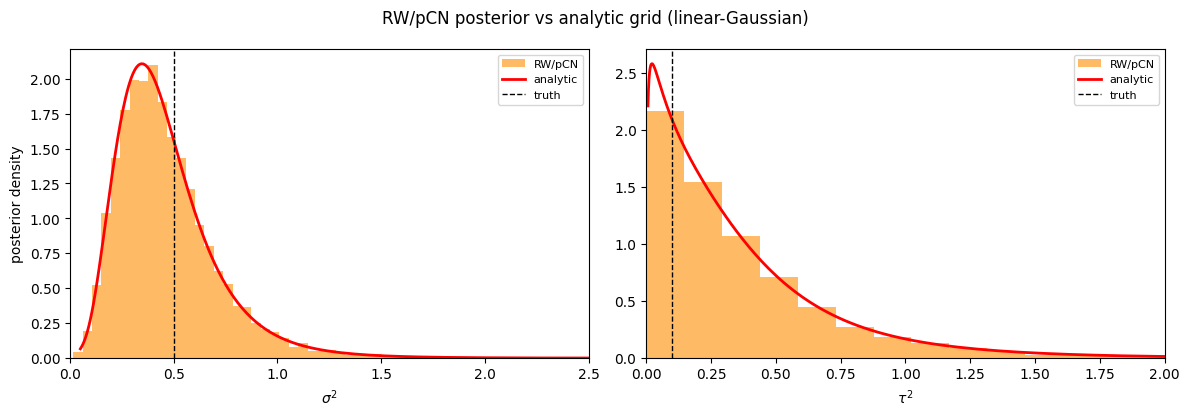

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
panels = [
    (r"$\sigma^2$", SIGMA_SQ_TRUE, s2g, p_s2, 2.5, 0),
    (r"$\tau^2$", TAU_SQ_TRUE, t2g, p_t2, 2.0, 1),
]
for name, truth, grid_x, dens, xmax, idx in panels:
    a = ax[idx]
    a.hist(samples[:, idx], bins=80, density=True, alpha=0.6, color="darkorange", label="RW/pCN")
    a.plot(np.asarray(grid_x), np.asarray(dens), "r-", lw=2, label="analytic")
    a.axvline(truth, color="k", ls="--", lw=1, label="truth")
    a.set_xlim(0, xmax)
    a.set_xlabel(name)
    a.legend(fontsize=8)
ax[0].set_ylabel("posterior density")
fig.suptitle("RW/pCN posterior vs analytic grid (linear-Gaussian)")
plt.tight_layout(); plt.show()


## 9. Non-linear teaser — what breaks when the auxiliary differs from the truth

So far the auxiliary process exactly matches the truth, so the importance weight collapses. Once we make the **true** transition covariance state-dependent — say, $Q_\text{true}(x) = \sigma^2(1 + 0.3\,x^2)\,I$ — the auxiliary $Q = \sigma^2 I$ no longer matches, and $\log w$ acquires genuine spread. Two consequences for our kernel:

1. The pCN accept ratio is now $\exp(\Delta \sum \log w)$, which is no longer $\equiv 1$. The pCN block does real work — proposals that increase $\sum \log w$ are accepted more often than proposals that decrease it.
2. The BFFG correction $\sum \log w$ shows up explicitly in the target, so the chain converges to the *true* posterior in spite of the linearised auxiliary.

This is the setting of [notebook 07](07_sde_mcmc.ipynb), where continuous-time SDE bridges (via `continuous_*` sweeps) replace the unit-edge discrete kernels here. Below we only demonstrate the first part — the spread of $\sum \log w$ — and leave the full nonlinear inference to 07.

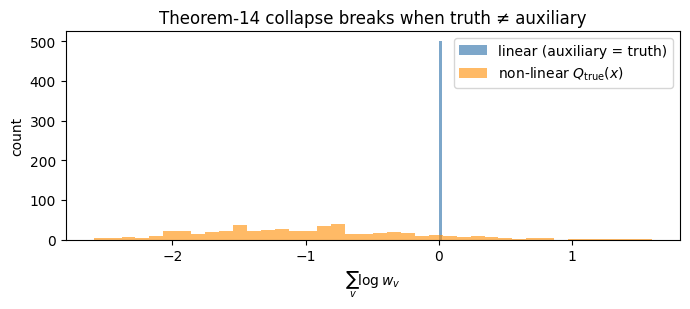

linear:     std(sum log_corr) = 0.00e+00
non-linear: std(sum log_corr) = 7.82e-01


In [16]:
def covar_fn_nl(x_pa, params):
    return params["sigma_sq"] * (1.0 + 0.3 * (x_pa ** 2)) * jnp.eye(1)


fg_nl = discrete_fg_sweep(
    mean_fn, covar_fn_nl, prxy_scale_fn, prxy_shift_fn, prxy_covar_fn
)
bf = discrete_bf_sweep(prxy_scale_fn, prxy_shift_fn, prxy_covar_fn)


@jax.jit
def bffg_nl_guided_forward(z, log_theta):
    sigma_sq = jnp.exp(log_theta[0])
    tau_sq = jnp.exp(log_theta[1])
    params = {"sigma_sq": sigma_sq}
    t = init_discrete_tree(empty, leaf_obs, obs_var=tau_sq, d=1, root_val=ROOT_VAL)
    t = bf(t, params=params)
    t = t.set(z=z[:, None])
    t = fg_nl(t, params=params)
    return t.val.squeeze(-1), t.log_corr.sum()


sums_nl = np.asarray(jax.vmap(lambda z: bffg_nl_guided_forward(z, lt_true)[1])(zs))
sums_lin = sums  # from §4

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(sums_lin, bins=40, alpha=0.7, label="linear (auxiliary = truth)", color="steelblue")
ax.hist(sums_nl, bins=40, alpha=0.6, label=r"non-linear $Q_{\text{true}}(x)$", color="darkorange")
ax.set_xlabel(r"$\sum_v \log w_v$")
ax.set_ylabel("count")
ax.set_title("Theorem-14 collapse breaks when truth ≠ auxiliary")
ax.legend()
plt.tight_layout(); plt.show()
print(f"linear:     std(sum log_corr) = {sums_lin.std():.2e}")
print(f"non-linear: std(sum log_corr) = {sums_nl.std():.2e}")


## Recap

1. **`hyperiax.prebuilt.bffg`** ships three building blocks: `init_discrete_tree`, `discrete_bf_sweep`, `discrete_fg_sweep`. Together they make a pure $(z, \log\theta) \mapsto (x, \sum \log w)$ map.
2. **Theorem-14 collapse holds empirically** to machine precision across 500 noise draws — the pCN block of any kernel built on top will accept 100% of proposals in this regime.
3. **A custom NumPyro `MCMCKernel`** (~30 lines, including a one-line pCN prior cancellation) plugs BFFG straight into NumPyro's `MCMC` driver. 4 chains × 8000 samples reproduce the analytic posterior to within ≈0.005 on means.
4. **State-dependent transitions break the collapse** — `sum log_corr` acquires genuine spread, the pCN accept ratio leaves the trivial 1.0 regime, and the BFFG correction does real work. That's the setting of notebook 07.

## Where to go next

- [`06_gaussian_nuts.ipynb`](06_gaussian_nuts.ipynb) — same model, same `numpyro.factor`, but the kernel is NumPyro's built-in **NUTS**. NUTS needs `jax.grad` of the potential, so the fact that it just runs against the BFFG pipeline is itself a demonstration of hyperiax's end-to-end differentiability.
- [`07_sde_mcmc.ipynb`](07_sde_mcmc.ipynb) — replace unit-edge discrete kernels with continuous-time SDE bridges via the `continuous_*` sweeps. The closed-form marginal disappears; BFFG becomes an approximation whose correction $\sum \log w$ actively keeps the chain on the true posterior.

## References

- van der Meulen, F. H. & Sommer, S. (2025). *Backward Filtering Forward Guiding.* JMLR **26**(281), 1–51. — Theorem 14 (nonlinear-Gaussian importance weight); Algorithm 1 (MCMC with parameter estimation). [arXiv:2505.18239](https://arxiv.org/abs/2505.18239)
- Cotter, S. L., Roberts, G. O., Stuart, A. M., White, D. (2013). *MCMC methods for functions: modifying old algorithms to make them faster.* Statistical Science **28**(3), 424–446. — pCN proposal.
- Phan, D., Pradhan, N., Jankowiak, M. (2019). *Composable Effects for Flexible and Accelerated Probabilistic Programming in NumPyro.* [arXiv:1912.11554](https://arxiv.org/abs/1912.11554)
